In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              precision_score, recall_score,
                              classification_report, confusion_matrix, roc_curve)
import joblib


In [4]:
df = pd.read_csv('diabetes_cdc.csv')
print('Shape:', df.shape)
df.head()


Shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
target_col = 'Diabetes_binary' if 'Diabetes_binary' in df.columns else 'Diabetes_012'
counts = df[target_col].value_counts()
print(counts)
print()
print(f"'Always predict 0' baseline = {counts[0]/len(df)*100:.2f}% accuracy")


Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

'Always predict 0' baseline = 84.24% accuracy


In [6]:
X = df.drop(columns=target_col)
y = df[target_col]

# If target has 3 classes (0=healthy, 1=prediabetic, 2=diabetic), make it binary
if y.nunique() > 2:
    y = (y >= 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, '  Test:', X_test.shape)


Train: (202944, 21)   Test: (50736, 21)


In [7]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)
y_proba_lr = lr.predict_proba(X_test_s)[:, 1]

print('Logistic Regression')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_lr):.4f}')


Logistic Regression
  Accuracy : 0.8481
  ROC-AUC  : 0.8172


In [8]:
hgb = HistGradientBoostingClassifier(
    max_iter=400, learning_rate=0.05, max_depth=6,
    l2_regularization=1.0, random_state=42)
hgb.fit(X_train, y_train)

y_pred = hgb.predict(X_test)
y_proba = hgb.predict_proba(X_test)[:, 1]

print('HistGradientBoosting (tuned)')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  F1       : {f1_score(y_test, y_pred):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred):.4f}')


HistGradientBoosting (tuned)
  Accuracy : 0.8517
  ROC-AUC  : 0.8243
  F1       : 0.2951
  Precision: 0.5881
  Recall   : 0.1970


In [9]:
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred,
                             target_names=['Not diabetic', 'Diabetic'], digits=4))


Confusion matrix:
[[41638  1103]
 [ 6420  1575]]

              precision    recall  f1-score   support

Not diabetic     0.8664    0.9742    0.9171     42741
    Diabetic     0.5881    0.1970    0.2951      7995

    accuracy                         0.8517     50736
   macro avg     0.7273    0.5856    0.6061     50736
weighted avg     0.8226    0.8517    0.8191     50736



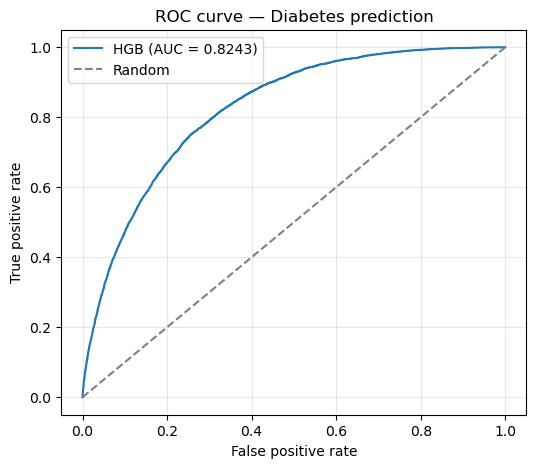

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'HGB (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], '--', color='grey', label='Random')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve — Diabetes prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


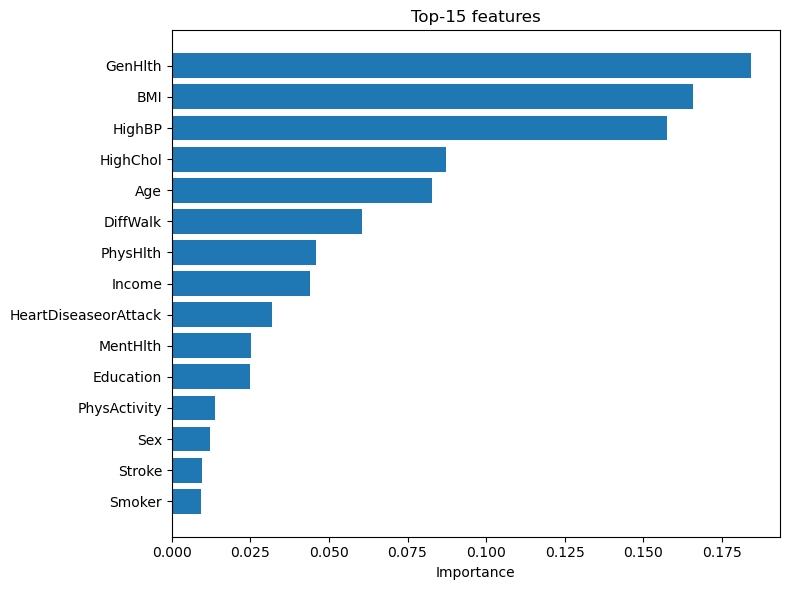

,feature,importance
0,GenHlth,0.184300
1,BMI,0.165711
2,HighBP,0.157717
3,HighChol,0.087095
4,Age,0.082792
5,DiffWalk,0.060355
6,PhysHlth,0.045867
7,Income,0.043860
8,HeartDiseaseorAttack,0.031957
9,MentHlth,0.025340


In [11]:
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

fi = (pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
       .sort_values('importance', ascending=False)
       .reset_index(drop=True))

plt.figure(figsize=(8, 6))
top = fi.head(15)
plt.barh(top['feature'][::-1], top['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top-15 features')
plt.tight_layout()
plt.show()

fi.head(15)


In [12]:
sample = pd.DataFrame([{
    'HighBP': 1, 'HighChol': 1, 'CholCheck': 1, 'BMI': 32, 'Smoker': 1,
    'Stroke': 0, 'HeartDiseaseorAttack': 0, 'PhysActivity': 0,
    'Fruits': 0, 'Veggies': 1, 'HvyAlcoholConsump': 0, 'AnyHealthcare': 1,
    'NoDocbcCost': 0, 'GenHlth': 4, 'MentHlth': 5, 'PhysHlth': 10,
    'DiffWalk': 1, 'Sex': 0, 'Age': 9, 'Education': 4, 'Income': 5,
}])[X.columns]

prob = hgb.predict_proba(sample)[0, 1]
pred = hgb.predict(sample)[0]
print(f'Probability of diabetes: {prob:.3f}')
print('Prediction:', 'Diabetic' if pred == 1 else 'Not diabetic')


Probability of diabetes: 0.478
Prediction: Not diabetic


In [13]:
joblib.dump(hgb, 'diabetes_model.joblib')
print('Model saved to diabetes_model.joblib')


Model saved to diabetes_model.joblib
